In [72]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
import joblib 

In [2]:
df = pd.read_csv('../data/car details v4.csv')

In [3]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [4]:
df.shape

(2059, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [6]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [7]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
numerical_features = df.select_dtypes(
    include = ['int64', 'float64']
).columns
categorical_features = df.select_dtypes(
    include= ['object']
).columns



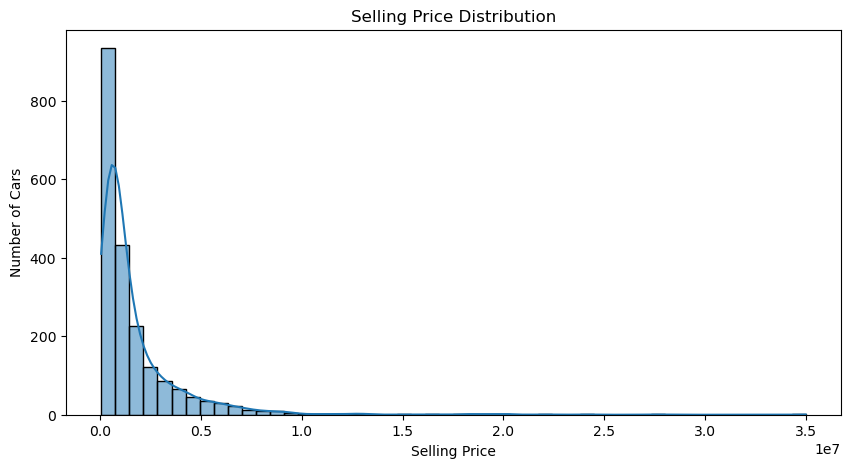

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Price"],
    bins=50,
    kde=True
)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

In [11]:
correlation = df[numerical_features].corr()

price_correlation = (
    correlation["Price"]
    .sort_values(ascending=False)
)

price_correlation

Price                 1.000000
Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Height                0.075080
Seating Capacity     -0.038524
Kilometer            -0.150825
Name: Price, dtype: float64

In [12]:
price_corr = (
    price_correlation
    .drop("Price")
    .abs()
    .sort_values(ascending=False)
)

price_corr

Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Kilometer             0.150825
Height                0.075080
Seating Capacity      0.038524
Name: Price, dtype: float64

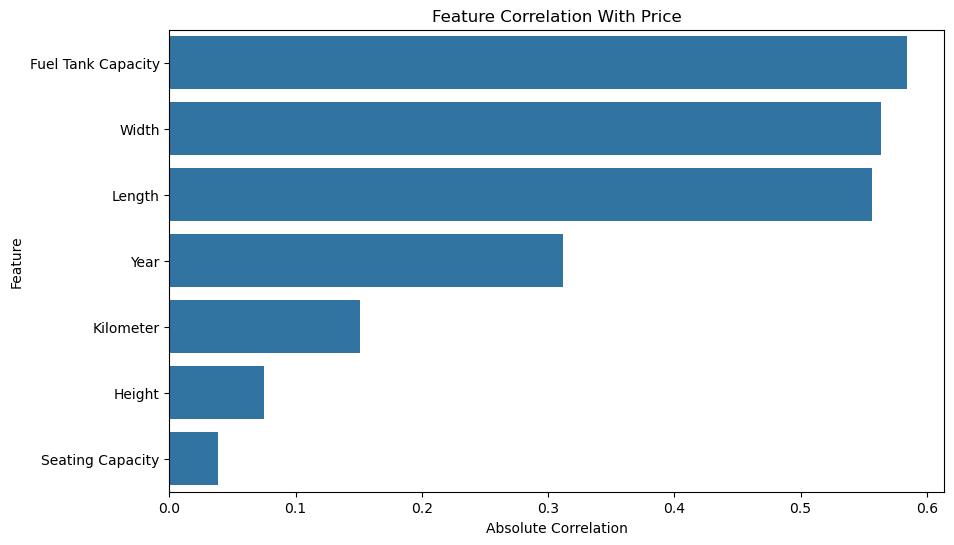

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=price_corr.values,
    y=price_corr.index
)

plt.title("Feature Correlation With Price")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

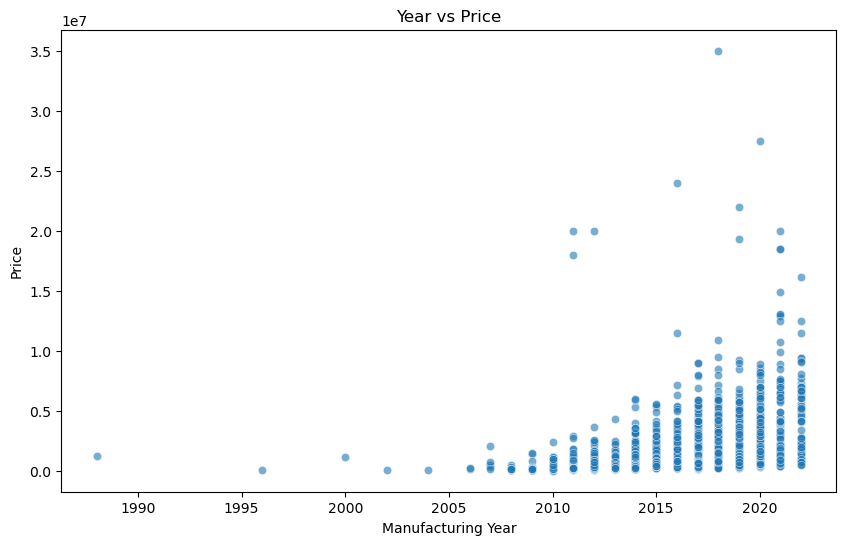

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Price",
    alpha=0.6
)

plt.title("Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price")

plt.show()

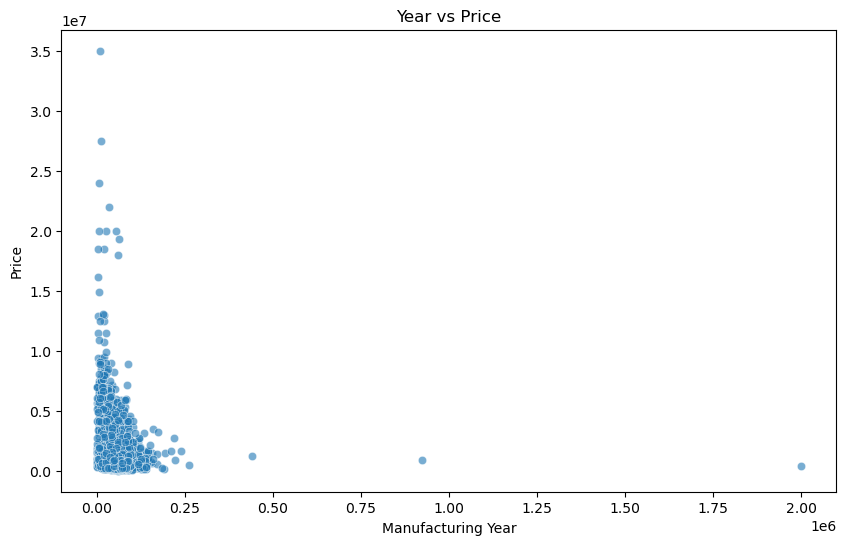

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Kilometer",
    y="Price",
    alpha=0.6
)

plt.title("Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price")

plt.show()

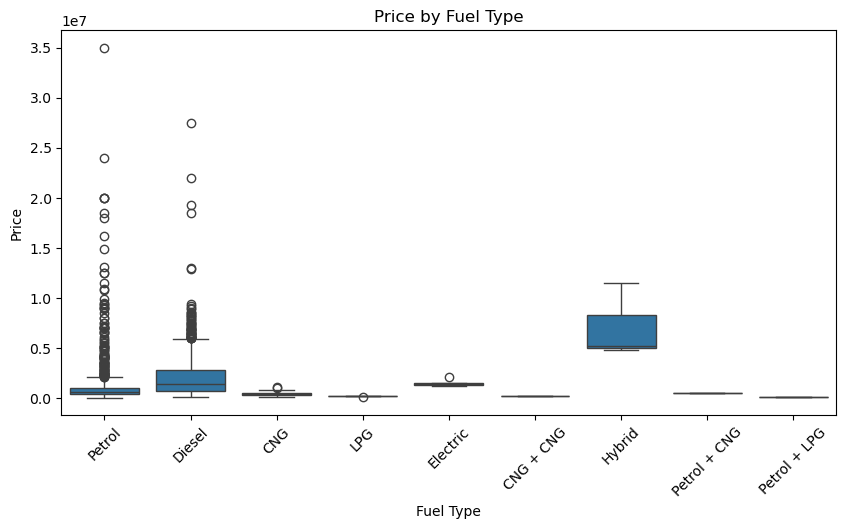

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Fuel Type",
    y="Price"
)

plt.title("Price by Fuel Type")

plt.xticks(rotation=45)

plt.show()

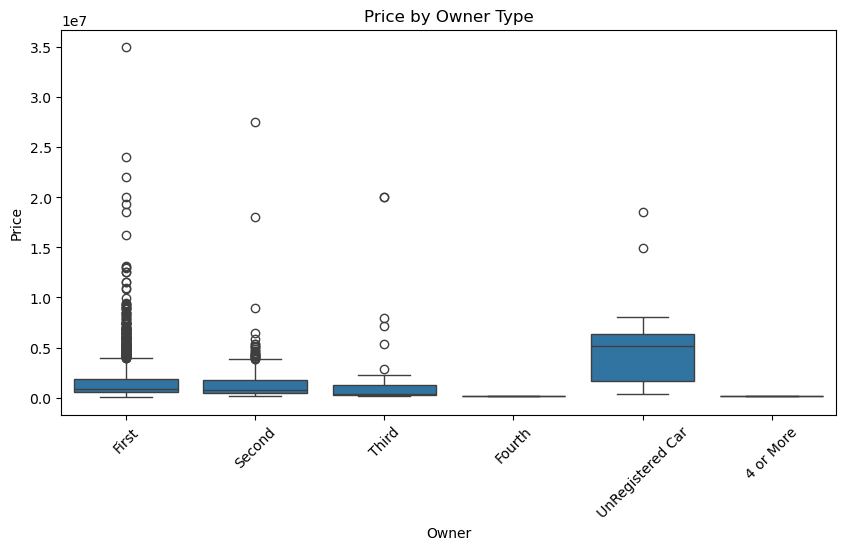

In [17]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Owner",
    y="Price"
)

plt.title("Price by Owner Type")

plt.xticks(rotation=45)

plt.show()

In [18]:
print("Engine:")
print(df["Engine"].dropna().head(10))

print("\nMax Power:")
print(df["Max Power"].dropna().head(10))

print("\nMax Torque:")
print(df["Max Torque"].dropna().head(10))

print("\nDrivetrain:")
print(df["Drivetrain"].dropna().value_counts())

Engine:
0    1198 cc
1    1248 cc
2    1197 cc
3    1197 cc
4    2393 cc
5    1373 cc
6    1991 cc
7    1995 cc
8    1798 cc
9    1461 cc
Name: Engine, dtype: object

Max Power:
0     87 bhp @ 6000 rpm
1     74 bhp @ 4000 rpm
2     79 bhp @ 6000 rpm
3     82 bhp @ 6000 rpm
4    148 bhp @ 3400 rpm
5     91 bhp @ 6000 rpm
6    181 bhp @ 5500 rpm
7    188 bhp @ 4000 rpm
8    177 bhp @ 5100 rpm
9     84 bhp @ 3750 rpm
Name: Max Power, dtype: object

Max Torque:
0         109 Nm @ 4500 rpm
1         190 Nm @ 2000 rpm
2    112.7619 Nm @ 4000 rpm
3         113 Nm @ 4200 rpm
4         343 Nm @ 1400 rpm
5         130 Nm @ 4000 rpm
6         300 Nm @ 1200 rpm
7         400 Nm @ 1750 rpm
8         250 Nm @ 1250 rpm
9         200 Nm @ 1900 rpm
Name: Max Torque, dtype: object

Drivetrain:
Drivetrain
FWD    1330
RWD     321
AWD     272
Name: count, dtype: int64


In [19]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

missing

Drivetrain            136
Fuel Tank Capacity    113
Engine                 80
Max Power              80
Max Torque             80
Length                 64
Width                  64
Height                 64
Seating Capacity       64
dtype: int64

In [20]:
df['Engine'] = (
    df['Engine']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

In [21]:
df['Max Torque'] = (
    df['Max Torque']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

In [22]:
df['Max Power'] = (
    df['Max Power']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   float64
 12  Max Power           1979 non-null   float64
 13  Max Torque          1979 non-null   float64
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [24]:
numeric_impute_columns = [
    "Engine",
    "Max Power",
    "Max Torque",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity"
]

In [25]:
for column in numeric_impute_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )

In [26]:
df["Drivetrain"] = df["Drivetrain"].fillna(
    "Unknown"
)

In [27]:
df.isnull().sum()

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

In [28]:
from datetime import datetime 

current_year = datetime.now().year

df['Car_age'] = current_year - df['Year']

In [29]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Car_age
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0,9
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0,12
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0,15
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0,7
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0,8


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              2059 non-null   float64
 12  Max Power           2059 non-null   float64
 13  Max Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

In [31]:
df['Car_age'].describe()

count    2059.000000
mean        9.574551
std         3.363564
min         4.000000
25%         7.000000
50%         9.000000
75%        12.000000
max        38.000000
Name: Car_age, dtype: float64

In [32]:
df['Car_age_for_calc'] = df['Car_age'].replace(
    0,1
)

df['km_per_year'] = (
    df['Kilometer'] / df['Car_age_for_calc']
)

In [33]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Car_age,Car_age_for_calc,km_per_year
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0,9,9,9683.333333
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0,12,12,6250.000000
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0,15,15,4466.666667
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0,7,7,5357.142857
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0,8,8,8625.000000


In [34]:
df.drop(
    columns = ['Car_age_for_calc'],
    inplace=True
)

In [35]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    print(
        f"{column:20} → {df[column].nunique()} unique values"
    )

Make                 → 33 unique values
Model                → 1050 unique values
Fuel Type            → 9 unique values
Transmission         → 2 unique values
Location             → 77 unique values
Color                → 17 unique values
Owner                → 6 unique values
Seller Type          → 3 unique values
Drivetrain           → 4 unique values


In [36]:
for column in categorical_columns:
    print("\n", "=" * 50)
    print(column)
    print("=" * 50)
    print(df[column].value_counts().head(10))


Make
Make
Maruti Suzuki    440
Hyundai          349
Mercedes-Benz    171
Honda            158
Toyota           132
Audi             127
BMW              121
Mahindra         119
Tata              57
Volkswagen        50
Name: count, dtype: int64

Model
Model
X1 sDrive20d xLine                       15
Swift DZire VDI                          14
City V                                   13
Fortuner 2.8 4x2 AT [2016-2020]          13
Swift DZire VXI                          12
Swift VXi [2014-2017]                    12
Swift VXi                                12
5-Series 520d Luxury Line [2017-2019]    10
A6 35 TDI Matrix                         10
Verna Fluidic 1.6 CRDi SX                10
Name: count, dtype: int64

Fuel Type
Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: count, dtype: int64

Transmission
Transmission
Manual     

In [37]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
numeric_features1 = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features1 = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric Features:")
print(numeric_features1)

print("\nCategorical Features:")
print(categorical_features1)

Numeric Features:
['Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Car_age', 'km_per_year']

Categorical Features:
['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Drivetrain']


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            "passthrough",
            numeric_features1
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2
            ),
            categorical_features1
        )

    ]

)

In [41]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [42]:
print("Original training shape:")
print(X_train.shape)

print("\nProcessed training shape:")
print(X_train_processed.shape)

Original training shape:
(1647, 21)

Processed training shape:
(1647, 502)


In [43]:
print(type(X_train_processed))

<class 'scipy.sparse._csr.csr_matrix'>


In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [45]:
import numpy as np 

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_pred,y_test)
    )
    mae = mean_absolute_error(y_pred, y_test)

    r2 = r2_score(y_pred, y_test)

    return rmse, mae, r2

In [46]:
linear_model = LinearRegression()

mae_lr, rmse_lr, r2_lr = evaluate_model(
    linear_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 1412104.2741656008
RMSE: 769060.4489170619
R²  : 0.4701274681459072


In [47]:
tree_model = DecisionTreeRegressor()

mae_dt, rmse_dt, r2_dt = evaluate_model(
    tree_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

print("Decision Tree ")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree 
MAE : 940077.6233314072
RMSE: 341932.0145631068
R²  : 0.813420353128554


In [48]:
rf_model = RandomForestRegressor()

mae_rf, rmse_rf, r2_rf = evaluate_model(
    rf_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 1083765.4123712964
RMSE: 302173.95228155336
R²  : 0.7093202947934301


In [49]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],

    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],

    "R2": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.412104e+06,769060.448917,0.470127
1,Decision Tree,9.400776e+05,341932.014563,0.813420
2,Random Forest,1.083765e+06,302173.952282,0.709320


In [50]:
import xgboost
print(xgboost.__version__)

3.4.0


In [51]:
from xgboost import XGBRegressor

In [52]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

mae_xgb, rmse_xgb, r2_xgb = evaluate_model(
    xgb_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 824860.4439540061
RMSE: 247734.890625
R²  : 0.8544812202453613


In [53]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ],

    "R2": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,8.248604e+05,247734.890625,0.854481
1,Decision Tree,9.400776e+05,341932.014563,0.813420
2,Random Forest,1.083765e+06,302173.952282,0.709320
0,Linear Regression,1.412104e+06,769060.448917,0.470127


In [54]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")
print(cv_scores)

print("\nMean CV R²:", cv_scores.mean())
print("Std CV R² :", cv_scores.std())

Cross-validation R² scores:
[0.65399259 0.85910499 0.81455249 0.89143777 0.9293853 ]

Mean CV R²: 0.8296946287155151
Std CV R² : 0.09561998257809479


In [55]:
from sklearn.model_selection import RandomizedSearchCV

In [56]:
param_grid = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5]
}

In [57]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [73]:
random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [74]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV R²:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV R²:
0.8667929887771606


In [75]:
best_xgb = random_search.best_estimator_

In [76]:
y_pred_tuned = best_xgb.predict(
    X_test_processed
)

In [77]:
mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

print("Tuned XGBoost")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned XGBoost
MAE : 250290.296875
RMSE: 855434.0265759833
R²  : 0.895256519317627


In [78]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,num__Max Power,0.154437
275,cat__Model_Range Rover 3.0 V6 Diesel Vogue,0.124147
399,cat__Fuel Type_Petrol,0.078625
6,num__Width,0.051511
5,num__Length,0.037240
41,cat__Make_infrequent_sklearn,0.034936
4,num__Max Torque,0.033444
401,cat__Transmission_Automatic,0.033208
9,num__Fuel Tank Capacity,0.029488
397,cat__Fuel Type_Hybrid,0.028527


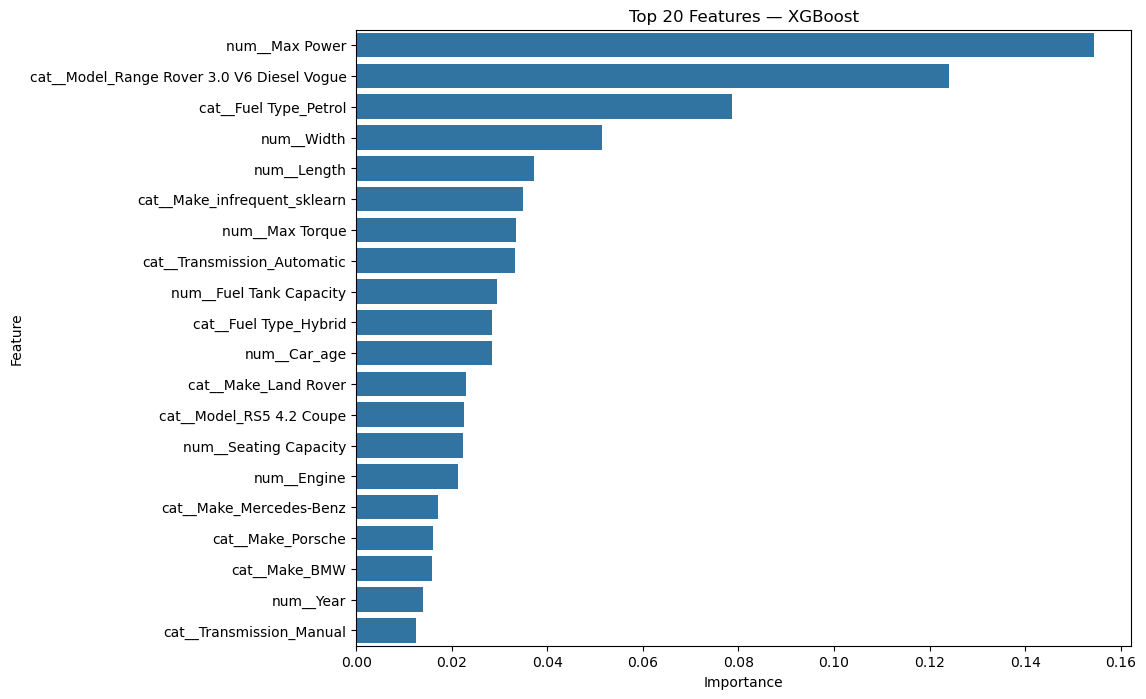

In [79]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

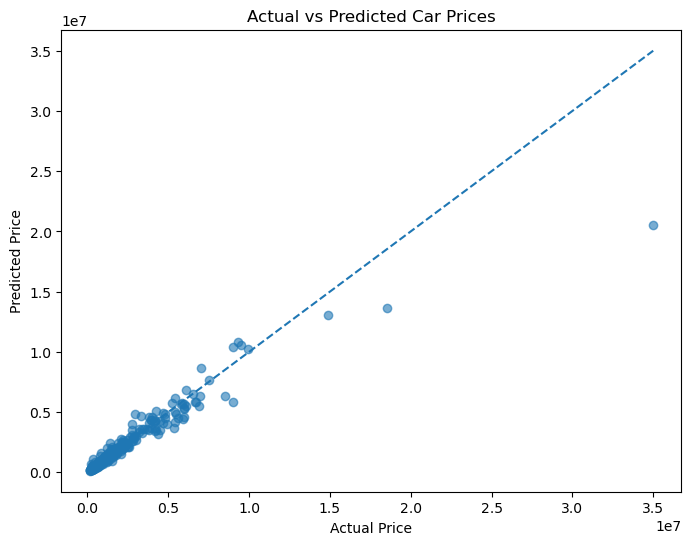

In [80]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

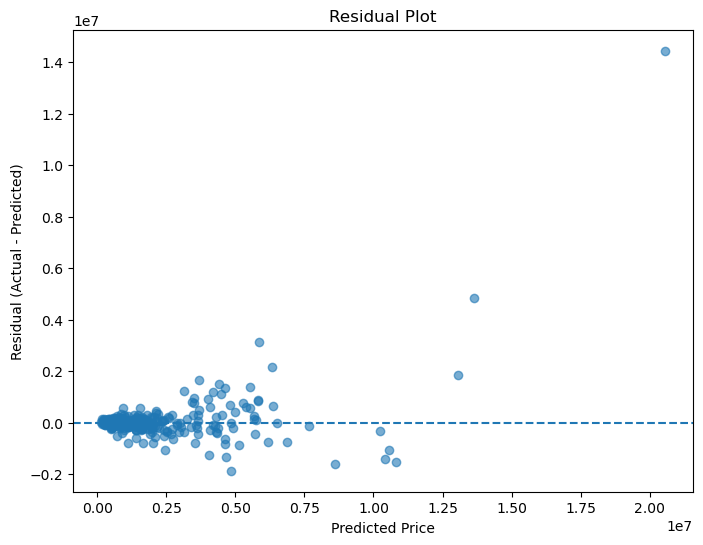

In [81]:
residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [82]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

joblib.dump(
    best_xgb,
    "../models/best_xgb_model.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [83]:
print(preprocessor.feature_names_in_)

['Make' 'Model' 'Year' 'Kilometer' 'Fuel Type' 'Transmission' 'Location'
 'Color' 'Owner' 'Seller Type' 'Engine' 'Max Power' 'Max Torque'
 'Drivetrain' 'Length' 'Width' 'Height' 'Seating Capacity'
 'Fuel Tank Capacity' 'Car_age' 'km_per_year']


In [84]:
print(preprocessor.get_feature_names_out())

['num__Year' 'num__Kilometer' 'num__Engine' 'num__Max Power'
 'num__Max Torque' 'num__Length' 'num__Width' 'num__Height'
 'num__Seating Capacity' 'num__Fuel Tank Capacity' 'num__Car_age'
 'num__km_per_year' 'cat__Make_Audi' 'cat__Make_BMW' 'cat__Make_Chevrolet'
 'cat__Make_Datsun' 'cat__Make_Fiat' 'cat__Make_Ford' 'cat__Make_Honda'
 'cat__Make_Hyundai' 'cat__Make_Jaguar' 'cat__Make_Jeep' 'cat__Make_Kia'
 'cat__Make_Land Rover' 'cat__Make_Lexus' 'cat__Make_MG' 'cat__Make_MINI'
 'cat__Make_Mahindra' 'cat__Make_Maruti Suzuki' 'cat__Make_Mercedes-Benz'
 'cat__Make_Mitsubishi' 'cat__Make_Nissan' 'cat__Make_Porsche'
 'cat__Make_Renault' 'cat__Make_Rolls-Royce' 'cat__Make_Skoda'
 'cat__Make_Ssangyong' 'cat__Make_Tata' 'cat__Make_Toyota'
 'cat__Make_Volkswagen' 'cat__Make_Volvo' 'cat__Make_infrequent_sklearn'
 'cat__Model_2 Series Gran Coupe 220d M Sport [2020-2021]'
 'cat__Model_3-Series 320d Luxury Line'
 'cat__Model_3-Series 320d Luxury Line [2014-2016]'
 'cat__Model_3-Series 320d Prestige'

In [85]:
print(df[["Year", "Kilometer", "Car_age", "km_per_year"]].head(10))

   Year  Kilometer  Car_age  km_per_year
0  2017      87150        9  9683.333333
1  2014      75000       12  6250.000000
2  2011      67000       15  4466.666667
3  2019      37500        7  5357.142857
4  2018      69000        8  8625.000000
5  2017      73315        9  8146.111111
6  2015      47000       11  4272.727273
7  2017      75000        9  8333.333333
8  2017      56000        9  6222.222222
9  2015      85000       11  7727.272727


In [86]:
print(df[["Year", "Kilometer", "Car_age", "km_per_year"]].describe())

              Year     Kilometer      Car_age    km_per_year
count  2059.000000  2.059000e+03  2059.000000    2059.000000
mean   2016.425449  5.422471e+04     9.574551    5585.272863
std       3.363564  5.736172e+04     3.363564    5785.543396
min    1988.000000  0.000000e+00     4.000000       0.000000
25%    2014.000000  2.900000e+04     7.000000    3451.000000
50%    2017.000000  5.000000e+04     9.000000    5137.625000
75%    2019.000000  7.200000e+04    12.000000    7000.000000
max    2022.000000  2.000000e+06    38.000000  200000.000000


In [87]:
categorical_cols = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission",
    "Location",
    "Color",
    "Owner",
    "Seller Type",
    "Drivetrain"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Make:
['Honda' 'Maruti Suzuki' 'Hyundai' 'Toyota' 'Mercedes-Benz' 'BMW' 'Skoda'
 'Nissan' 'Renault' 'Tata' 'Volkswagen' 'Ford' 'Audi' 'Mahindra' 'MG'
 'Jeep' 'Porsche' 'Kia' 'Land Rover' 'Volvo' 'Maserati' 'Jaguar' 'Isuzu'
 'Fiat' 'MINI' 'Ferrari' 'Mitsubishi' 'Datsun' 'Lamborghini' 'Chevrolet'
 'Ssangyong' 'Rolls-Royce' 'Lexus']

Model:
['Amaze 1.2 VX i-VTEC' 'Swift DZire VDI' 'i10 Magna 1.2 Kappa2' ...
 'Ritz Vxi (ABS) BS-IV' 'XUV500 W8 [2015-2017]'
 'Figo Duratec Petrol ZXI 1.2']

Fuel Type:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric' 'CNG + CNG' 'Hybrid'
 'Petrol + CNG' 'Petrol + LPG']

Transmission:
['Manual' 'Automatic']

Location:
['Pune' 'Ludhiana' 'Lucknow' 'Mangalore' 'Mumbai' 'Coimbatore' 'Bangalore'
 'Delhi' 'Raipur' 'Kanpur' 'Patna' 'Vadodara' 'Hyderabad' 'Yamunanagar'
 'Gurgaon' 'Jaipur' 'Deoghar' 'Agra' 'Goa' 'Warangal' 'Jalandhar' 'Noida'
 'Ahmedabad' 'Mohali' 'Navi Mumbai' 'Ghaziabad' 'Kolkata' 'Zirakpur'
 'Nagpur' 'Thane' 'Faridabad' 'Ranchi' 'Chandigarh' 'Amritsar' 'C

In [88]:
make_model_map = (
    df.groupby("Make")["Model"]
    .unique()
    .apply(list)
    .to_dict()
)

make_model_map

{'Audi': ['A4 2.0 TDI (177bhp) Premium Plus',
  'A4 2.0 TDI (143 bhp)',
  'A3 35 TDI Technology + Sunroof',
  'Q3 35 TDI quattro Premium Plus',
  'A6 2.0 TDI Premium',
  'Q2 Premium Plus I 40 TFSI quattro',
  'Q7 45 TDI Premium Plus',
  'Q5 45 TFSI Premium Plus',
  'A6 35 TDI Matrix',
  'A6 35 TDI Premium',
  'Q7 3.0 TDI quattro Premium Plus',
  'Q3 2.0 TDI quattro Premium',
  'RS5 4.2 Coupe',
  'A6 2.0 TFSi Technology Pack',
  'Q7 35 TDI Premium + Sunroof',
  'Q3 2.0 TDI quattro Premium Plus',
  'Q3 35 TDI Premium + Sunroof',
  'TT 2.0 TFSI Quattro',
  'Q3 35 TDI Premium',
  'A4 35 TDI Technology',
  'A3 35 TDI Premium + Sunroof',
  'A4 30 TFSI Technology Pack',
  'A4 2.0 TDI Sline',
  'Q7 Technology 55 TFSI',
  'Q5 2.0 TDI quattro Premium Plus',
  'A4 1.8 TFSI Multitronic Premium Plus',
  'A3 35 TDI Premium Plus',
  'A4 2.0 TDI (177bhp) Premium',
  'A3 35 TDI Premium',
  'A3 40 TFSI Premium Plus + sunroof',
  'A6 3.0 TDI quattro Premium',
  'A6 2.0 TDI Premium Plus',
  'A4 30 TFSI Pr

In [89]:
import joblib

joblib.dump(
    make_model_map,
    "../models/make_model_map.pkl"
)

['../models/make_model_map.pkl']

In [90]:
car_specs = df[
    [
        "Make",
        "Model",
        "Engine",
        "Max Power",
        "Max Torque",
        "Length",
        "Width",
        "Height",
        "Seating Capacity",
        "Fuel Tank Capacity"
    ]
].drop_duplicates(
    subset=["Make", "Model"]
)

In [91]:
car_specs_dict = car_specs.set_index(
    ["Make", "Model"]
).to_dict(
    orient="index"
)

In [92]:
import joblib

joblib.dump(
    car_specs_dict,
    "../models/car_specs.pkl"
)

print("car_specs.pkl saved!")

car_specs.pkl saved!


In [93]:
car_specs_dict[("Honda", "Amaze 1.2 VX i-VTEC")]

{'Engine': 1198.0,
 'Max Power': 87.0,
 'Max Torque': 109.0,
 'Length': 3990.0,
 'Width': 1680.0,
 'Height': 1505.0,
 'Seating Capacity': 5.0,
 'Fuel Tank Capacity': 35.0}